In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# 1. Carregar os Dados
df = pd.read_json("final_dataset_tqs_final.json")
MAX_ASSERT_TYPES = 5.0  # Ajuste conforme o seu limite teórico

# Limpeza Preventiva de Coverage
if df['coverage'].dtype == 'O': 
    df['coverage'] = df['coverage'].astype(str).str.replace('%', '').astype(float) / 100.0

# ==========================================
# CÁLCULO DOS COMPONENTES (A1 a A8) PARA VETORES
# ==========================================
# A1: Baseline Passed (1.0 ou 0.0)
df['a1'] = np.where(df['baseline_passed'] == True, 1.0, 0.0)

# A2: Edge Cases (1.0 ou 0.0)
df['a2'] = np.where(df['edge_case_found'] == True, 1.0, 0.0)

# A3: Code Coverage (0.0 a 1.0)
df['a3'] = df['coverage'].fillna(0.0).astype(float)

# A4: Functional Coverage
# Evita divisão por zero retornando 0.0 se não houver functions_tested ou total_functions
df['a4'] = np.where((df['functions_tested'] > 0) & (df['total_functions'] > 0),
                    0.5 * (df['functions_tested'] / df['total_functions']),
                    0.0)

# A5: Assertion Diversity (Máximo de 0.30)
df['assert_count'] = df['assert_types'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['a5'] = np.minimum(df['assert_count'] / MAX_ASSERT_TYPES, 1.0) * 0.30

# A6: Execution Failure
df['a6'] = np.where(df['baseline_passed'] == False, -1.0, 0.0)

# A7: Syntax Error
df['a7'] = 0.0

# A8: Test Smells (-0.2 por tipo)
df['smell_count'] = df['test_smells'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['a8'] = df['smell_count'] * -0.2

# ==========================================
# VETORES E TQS
# ==========================================
# Vetor de Potencial (V_P): Soma dos atributos positivos para o Gráfico da RQ1
df['V_P'] = df['a1'] + df['a2'] + df['a3'] + df['a4'] + df['a5']

# Vetor de Ruído (V_N): Magnitude (valor absoluto) das penalizações para o Gráfico da RQ2
df['V_N'] = (df['a6'] + df['a7'] + df['a8']).abs()

# O TQS final não é recalculado, usamos a coluna 'tqs' original que veio do JSON
# df['tqs_recalculado'] -> Foi removido!

# 2. Filtrar apenas testes válidos e remover Mutation Score == 0 (testes degenerados)
df_valid = df[(df['baseline_passed'] == True) & (df['mutation_score'] > 0.0)].copy()

# Configuração visual global
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

print(f"Dataset carregado e preparado! Total de testes para análise: {len(df_valid)}")
# Mostramos as métricas decompostas junto com o 'tqs' oficial do JSON
display(df_valid[['llm', 'mutation_score', 'V_P', 'V_N', 'tqs']].head())

Dataset carregado e preparado! Total de testes para análise: 45


,llm,mutation_score,V_P,V_N,tqs
0,CodeGemma,1.000,3.56,0.2,4.6667
1,CodeGemma,1.000,3.56,0.2,4.6667
2,Gemma,1.000,3.56,0.2,4.6667
3,CodeGemma,0.926,3.56,0.4,4.1667
4,CodeLLaMA,0.907,3.56,0.4,4.1667


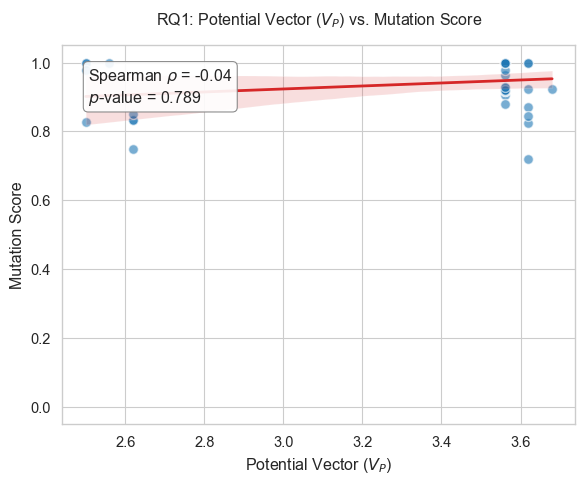

In [6]:
# =========================================================
# RQ1: Correlação do Vetor de Potencial
# =========================================================
plt.figure(figsize=(6, 5))

# Scatter plot com linha de regressão
sns.regplot(data=df_valid, x='V_P', y='mutation_score', 
            scatter_kws={'alpha': 0.6, 'color': '#1f77b4', 'edgecolor': 'w', 's': 50}, 
            line_kws={'color': '#d62728', 'linewidth': 2})

# Estatística: Correlação de Spearman
rho_vp, p_vp = stats.spearmanr(df_valid['V_P'], df_valid['mutation_score'])

# Caixa de anotação com o valor de Spearman
texto_stat = f'Spearman $\\rho$ = {rho_vp:.2f}\n$p$-value = {p_vp:.3f}'
plt.annotate(texto_stat, xy=(0.05, 0.85), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))

plt.title('RQ1: Potential Vector ($V_P$) vs. Mutation Score', pad=15)
plt.xlabel('Potential Vector ($V_P$)')
plt.ylabel('Mutation Score')
plt.ylim(-0.05, 1.05)
plt.tight_layout()

plt.savefig('RQ1_VP_Correlation.pdf', format='pdf', dpi=300)
plt.show()

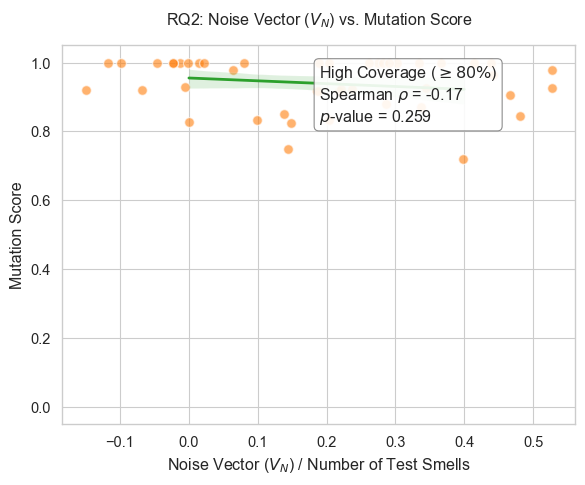

In [7]:
# =========================================================
# RQ2: Impacto Negativo do Ruído (Test Smells)
# =========================================================
# Filtrar apenas para os testes "ilusórios" (Cobertura >= 80%)
df_high_cov = df_valid[df_valid['coverage'] >= 0.80].copy()

plt.figure(figsize=(6, 5))

# Adicionar um pequeno "jitter" (ruído visual) no eixo X porque V_N são números inteiros,
# isso evita que os pontos fiquem todos sobrepostos.
sns.regplot(data=df_high_cov, x='V_N', y='mutation_score', x_jitter=0.15,
            scatter_kws={'alpha': 0.6, 'color': '#ff7f0e', 'edgecolor': 'w', 's': 50}, 
            line_kws={'color': '#2ca02c', 'linewidth': 2})

rho_vn, p_vn = stats.spearmanr(df_high_cov['V_N'], df_high_cov['mutation_score'])

texto_stat = f'High Coverage ($\\geq 80\\%$)\nSpearman $\\rho$ = {rho_vn:.2f}\n$p$-value = {p_vn:.3f}'
plt.annotate(texto_stat, xy=(0.50, 0.80), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))

plt.title('RQ2: Noise Vector ($V_N$) vs. Mutation Score', pad=15)
plt.xlabel('Noise Vector ($V_N$) / Number of Test Smells')
plt.ylabel('Mutation Score')
plt.ylim(-0.05, 1.05)
plt.tight_layout()

plt.savefig('RQ2_VN_Impact.pdf', format='pdf', dpi=300)
plt.show()

C:\Users\antho\AppData\Local\Temp\ipykernel_28492\2913634844.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_cov, _ = stats.spearmanr(df_valid['coverage'], df_valid['mutation_score'])


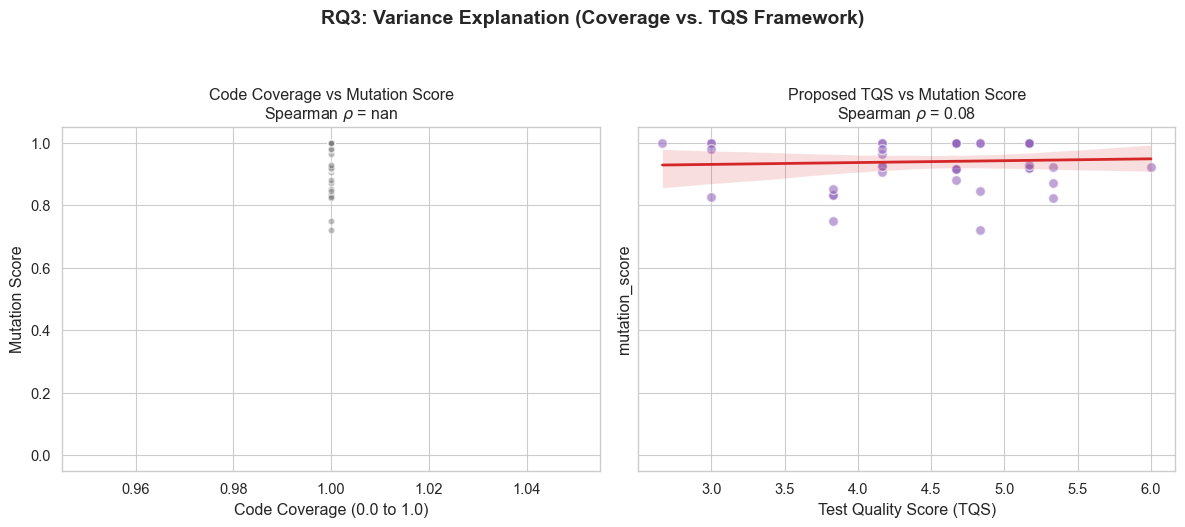

In [8]:
# =========================================================
# RQ3: TQS vs Code Coverage (Subplots Lado-a-Lado)
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# --- Subplot 1: Cobertura de Código ---
sns.regplot(ax=axes[0], data=df_valid, x='coverage', y='mutation_score',
            scatter_kws={'alpha': 0.5, 'color': '#7f7f7f', 'edgecolor': 'w'},
            line_kws={'color': 'black', 'linestyle': '--'})

rho_cov, _ = stats.spearmanr(df_valid['coverage'], df_valid['mutation_score'])
axes[0].set_title(f'Code Coverage vs Mutation Score\nSpearman $\\rho$ = {rho_cov:.2f}')
axes[0].set_xlabel('Code Coverage (0.0 to 1.0)')
axes[0].set_ylabel('Mutation Score')
axes[0].set_ylim(-0.05, 1.05)

# --- Subplot 2: TQS ---
sns.regplot(ax=axes[1], data=df_valid, x='tqs', y='mutation_score',
            scatter_kws={'alpha': 0.6, 'color': '#9467bd', 'edgecolor': 'w', 's': 50},
            line_kws={'color': '#d62728', 'linewidth': 2})

rho_tqs, _ = stats.spearmanr(df_valid['tqs'], df_valid['mutation_score'])
axes[1].set_title(f'Proposed TQS vs Mutation Score\nSpearman $\\rho$ = {rho_tqs:.2f}')
axes[1].set_xlabel('Test Quality Score (TQS)')

fig.suptitle('RQ3: Variance Explanation (Coverage vs. TQS Framework)', y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('RQ3_TQS_vs_Coverage.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()